In [1]:
from sklearn.linear_model import LinearRegression

import numpy as np
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

prediction = model.predict(np.array([[7]]))
print(f"prediction: {prediction}")

prediction: [[14.]]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# تحميل البيانات
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

# استعراض أول 5 صفوف
print(df.head())
print(f"\ data shape: {df.shape}")
print(f"\ statistics:\n{df.describe().round(2)}")

<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_53472/2984655500.py:16: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ data shape: {df.shape}")
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_53472/2984655500.py:17: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ statistics:\n{df.describe().round(2)}")


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
\ data shape: (20640, 9)
\ statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2

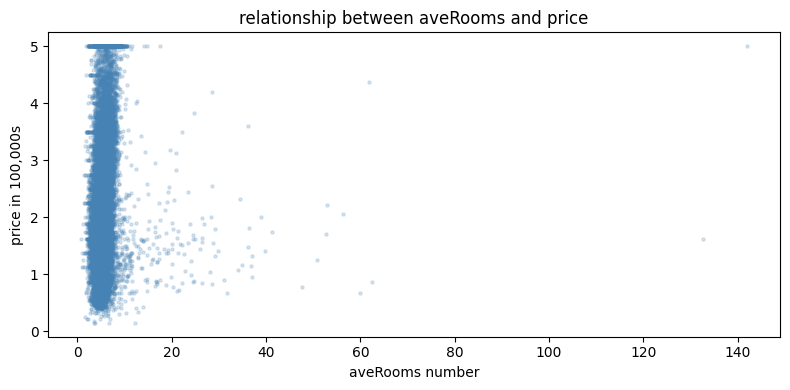

house number: 20640
average price: $2.07 * 100,000


In [3]:
# رسم العلاقة بين متوسط الغرف والسعر
plt.figure(figsize=(8, 4))
plt.scatter(df['AveRooms'], df['Price'], alpha=0.2, color='steelblue', s=5)
plt.xlabel('aveRooms number')
plt.ylabel('price in 100,000s')
plt.title('relationship between aveRooms and price')
plt.tight_layout()
plt.show()

# كم منزل في البيانات؟
print(f"house number: {len(df)}")
print(f"average price: ${df['Price'].mean():.2f} * 100,000")

In [4]:
# اختيار الـ features
features = ['AveRooms', 'AveBedrms', 'Population', 'MedInc']
X = df[features]
y = df['Price']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"train data: {X_train.shape}")
print(f"test data: {X_test.shape}")

# تدريب الموديل
model = LinearRegression()
model.fit(X_train, y_train)

print("model finish training:")
print(f"Weight (Coefficients): {model.coef_.round(3)}")
print(f"Bias (Intercept): {model.intercept_:.3f}")

train data: (16512, 4)
test data: (4128, 4)
model finish training:
Weight (Coefficients): [-0.248  1.171 -0.     0.543]
Bias (Intercept): 0.079


R² Score: 0.486
RMSE: 0.821 (بالمئة ألف دولار)


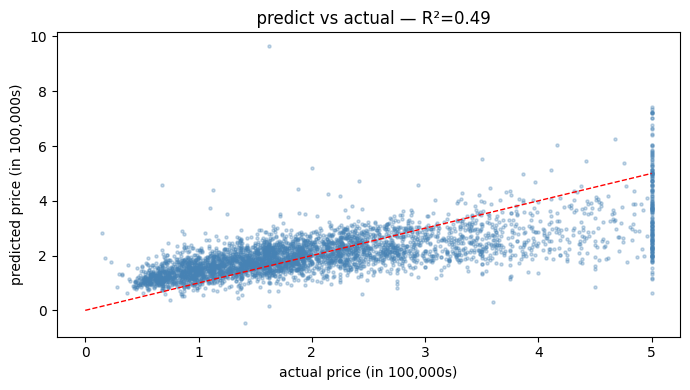

In [5]:
# التنبؤ
y_pred = model.predict(X_test)

# مقاييس الدقة
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f} (بالمئة ألف دولار)")

# رسم التنبؤات مقابل الواقع
plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=1)
plt.xlabel('actual price (in 100,000s)')
plt.ylabel('predicted price (in 100,000s)')
plt.title(f'  predict vs actual — R²={r2:.2f}')
plt.tight_layout()
plt.show()

In [6]:
# تحدي: استخدم كل الـ features بدل 4 فقط
X_full = df[data.feature_names]
y_full = df['Price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)


r2_full = r2_score(y_test2, y_pred2)
print(f"R² مع 4 features: {r2:.3f}")
print(f"R² مع كل الـ features: {r2_full:.3f}")
print(f"التحسن: +{(r2_full - r2):.3f}")


rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))


print(f"RMSE: {rmse2:.3f} (بالمئة ألف دولار)")

R² مع 4 features: 0.486
R² مع كل الـ features: 0.576
التحسن: +0.090
RMSE: 0.746 (بالمئة ألف دولار)
